In [32]:
from simulador import simular_ciudad
import importlib
import simulador
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
importlib.reload(simulador)
import pandas as pd

In [17]:
print(simulador.CARPETA_DATA)
print(simulador.CARPETA_DATA.resolve())
print((simulador.CARPETA_DATA / "madrid").exists())
print((simulador.CARPETA_DATA / "madrid" / "puntos_b2c.csv").exists())

E:\UPV\Proyectos\GLIMS\data
E:\UPV\Proyectos\GLIMS\data
True
True


In [18]:
ciudad = "valencia"

df_resultados = simular_ciudad(
    ciudad=ciudad,
    barrio_activo=None
)

df_resultados.round(2)


📍 Simulando VALENCIA - Benicalap
✅ Benicalap: 60 paquetes simulados

📍 Simulando VALENCIA - Camins al Grau
✅ Camins al Grau: 133 paquetes simulados

📍 Simulando VALENCIA - La Punta
✅ La Punta: 6 paquetes simulados


,ciudad,barrio,modelo,centro_logistico,paquetes,distancia_troncal_km,km_recorridos,numero_viajes,emisiones_co2_kg,costo_total_eur
0,valencia,Benicalap,M1: Furgoneta Combustión desde CC,Amazon VLC1,60,58.21,127.36,1,28.02,161.52
1,valencia,Benicalap,M2: Furgoneta Eléctrica desde CC,Amazon VLC1,60,58.21,127.36,1,0.00,140.10
2,valencia,Benicalap,M3: CC -> Microhub -> Bicicleta,Amazon VLC1,60,58.21,129.01,4,25.61,110.60
3,valencia,Benicalap,M4: CC -> PUDO -> Entrega a pie,Amazon VLC1,60,58.21,179.10,6,25.61,249.53
4,valencia,Benicalap,M5: CC -> PUDO -> Recogida Cliente,Amazon VLC1,60,58.21,179.10,61,27.18,82.39
5,valencia,Camins al Grau,M1: Furgoneta Combustión desde CC,Amazon VLC1,133,59.69,378.03,3,83.17,479.42
6,valencia,Camins al Grau,M2: Furgoneta Eléctrica desde CC,Amazon VLC1,133,59.69,378.03,3,0.00,415.84
7,valencia,Camins al Grau,M3: CC -> Microhub -> Bicicleta,Amazon VLC1,133,59.69,142.23,8,26.27,122.71
8,valencia,Camins al Grau,M4: CC -> PUDO -> Entrega a pie,Amazon VLC1,133,59.69,318.93,13,26.27,652.32
9,valencia,Camins al Grau,M5: CC -> PUDO -> Recogida Cliente,Amazon VLC1,133,59.69,318.93,134,31.25,120.23


In [19]:
carpeta_ciudad = Path("../results") / ciudad
carpeta_ciudad.mkdir(
    parents=True,
    exist_ok=True
)

# Resumen completo

df_resultados.to_csv(
    carpeta_ciudad / f"resumen_{ciudad}.csv",
    index=False,
    encoding="utf-8-sig"
)


for barrio, df_barrio in df_resultados.groupby("barrio"):

    nombre_archivo = (
        barrio
        .replace(" ", "_")
        .replace("á", "a")
        .replace("é", "e")
        .replace("í", "i")
        .replace("ó", "o")
        .replace("ú", "u")
    )

    df_barrio.to_csv(
        carpeta_ciudad / f"{nombre_archivo}.csv",
        index=False,
        encoding="utf-8-sig"
    )

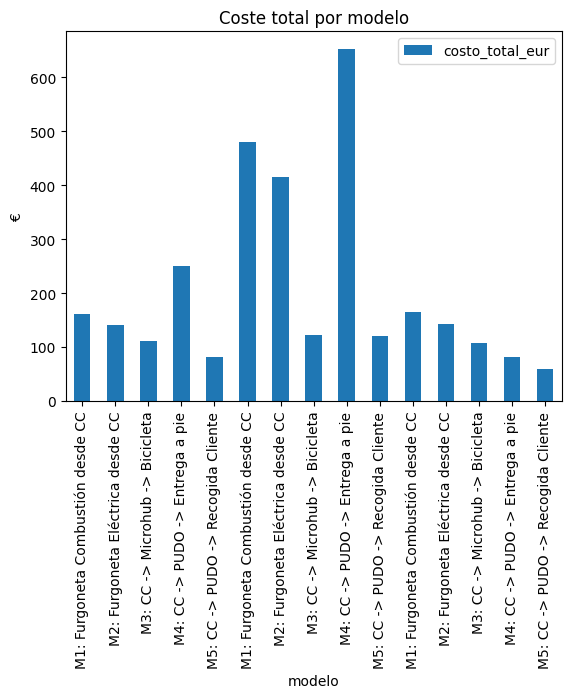

In [20]:
df_resultados.plot(
    x="modelo",
    y="costo_total_eur",
    kind="bar"
)
plt.title("Coste total por modelo")
plt.ylabel("€")
plt.show()

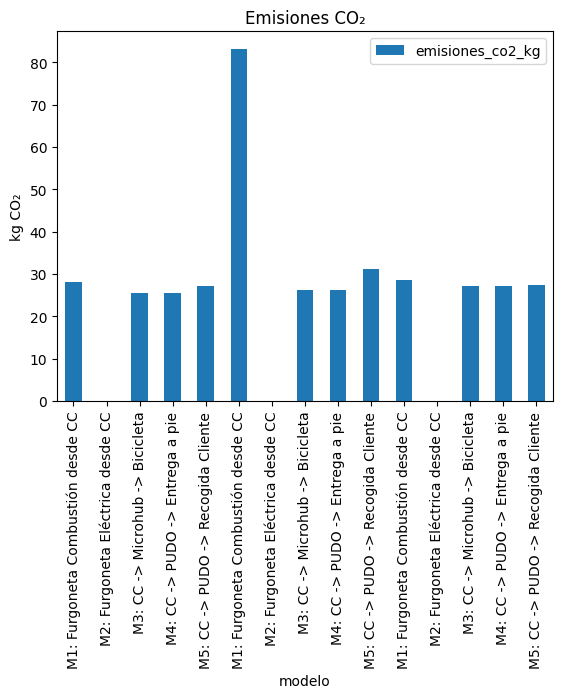

In [21]:
df_resultados.plot(
    x="modelo",
    y="emisiones_co2_kg",
    kind="bar"
)

plt.title("Emisiones CO₂")
plt.ylabel("kg CO₂")
plt.show()

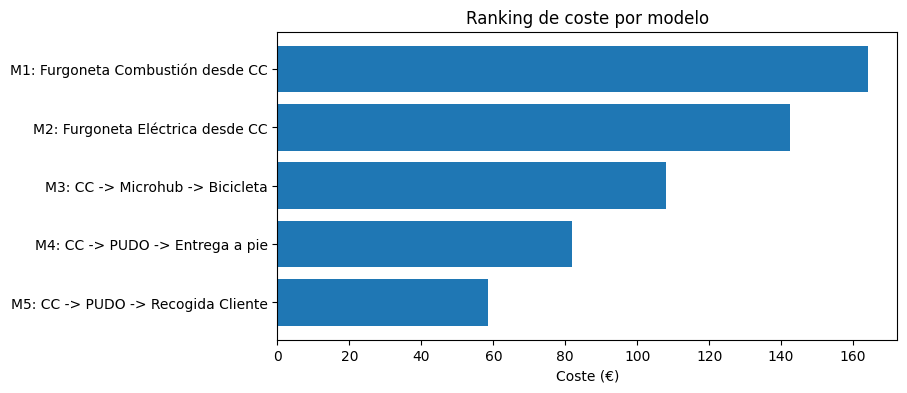

In [22]:
df_plot = (
    df_resultados[df_resultados["barrio"]=="La Punta"]
    .sort_values("costo_total_eur")
)

plt.figure(figsize=(8,4))

plt.barh(
    df_plot["modelo"],
    df_plot["costo_total_eur"]
)

plt.xlabel("Coste (€)")
plt.title("Ranking de coste por modelo")
plt.show()

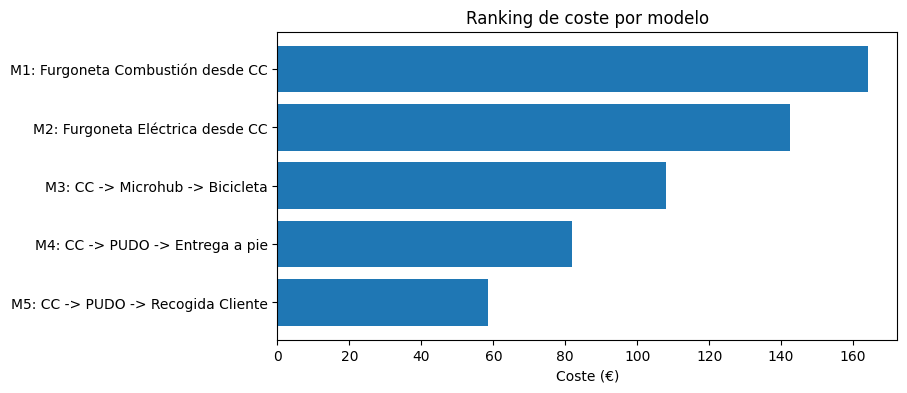

In [23]:
df_plot = (
    df_resultados[df_resultados["barrio"]=="La Punta"]
    .sort_values("costo_total_eur")
)

plt.figure(figsize=(8,4))

plt.barh(
    df_plot["modelo"],
    df_plot["costo_total_eur"]
)

plt.xlabel("Coste (€)")
plt.title("Ranking de coste por modelo")
plt.show()



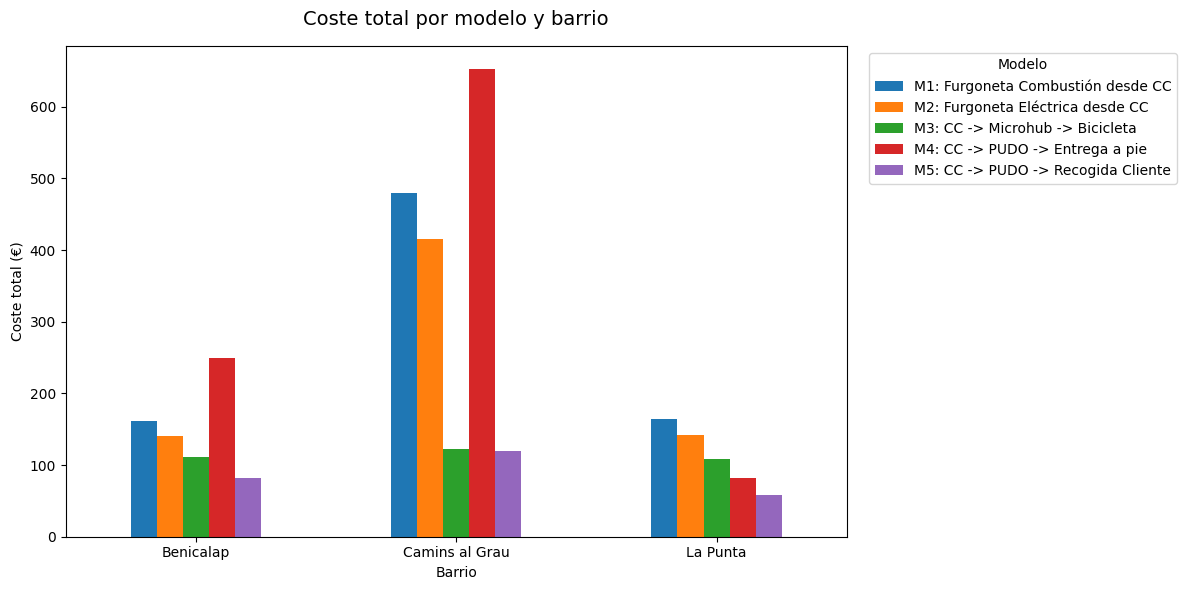

In [ ]:
import matplotlib.pyplot as plt

pivot_coste = df_resultados.pivot_table(
    index="barrio",
    columns="modelo",
    values="costo_total_eur"
)


fig, ax = plt.subplots(figsize=(12, 6))

pivot_coste.plot(
    kind="bar",
    ax=ax
)

ax.set_title(
    "Coste total por modelo y barrio",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Barrio")
ax.set_ylabel("Coste total (€)")

ax.legend(
    title="Modelo",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

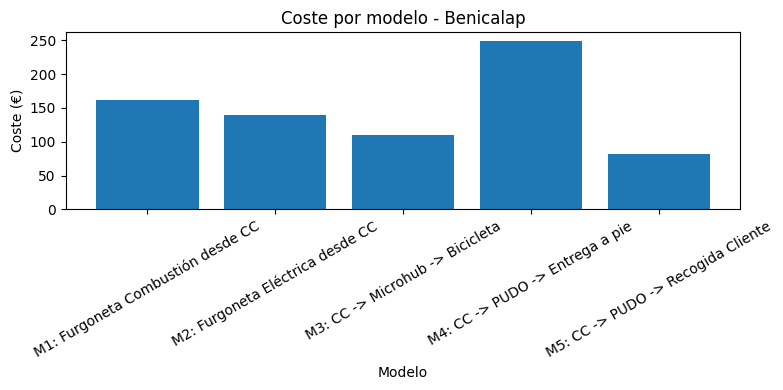

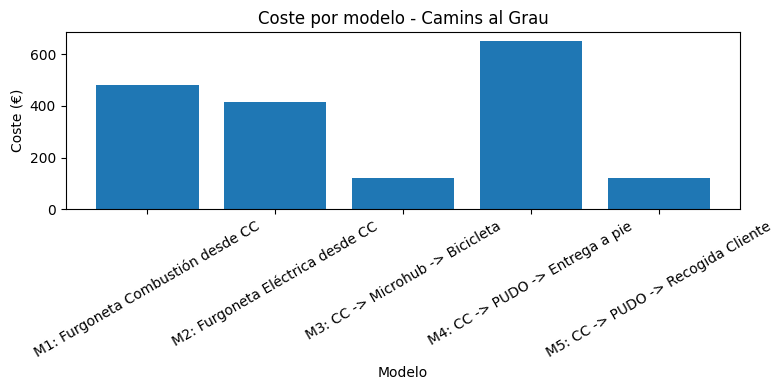

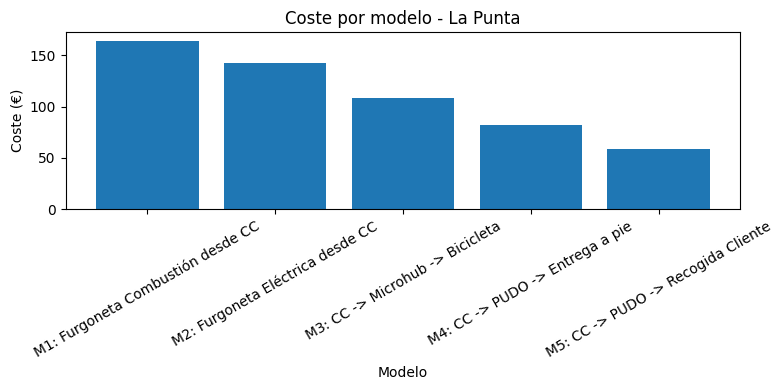

In [25]:
import matplotlib.pyplot as plt

for barrio in df_resultados["barrio"].unique():

    df_barrio = df_resultados[
        df_resultados["barrio"] == barrio
    ]

    plt.figure(figsize=(8, 4))

    plt.bar(
        df_barrio["modelo"],
        df_barrio["costo_total_eur"]
    )

    plt.title(f"Coste por modelo - {barrio}")
    plt.ylabel("Coste (€)")
    plt.xlabel("Modelo")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()

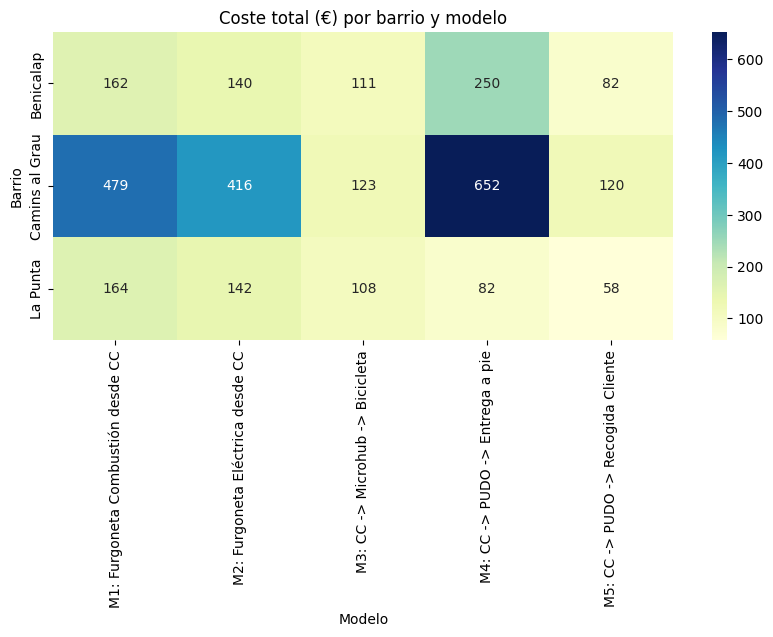

In [26]:
import seaborn as sns

tabla = df_resultados.pivot_table(
    index="barrio",
    columns="modelo",
    values="costo_total_eur"
)

plt.figure(figsize=(10, 4))

sns.heatmap(
    tabla,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Coste total (€) por barrio y modelo")
plt.xlabel("Modelo")
plt.ylabel("Barrio")

plt.show()

<Axes: xlabel='modelo', ylabel='barrio'>

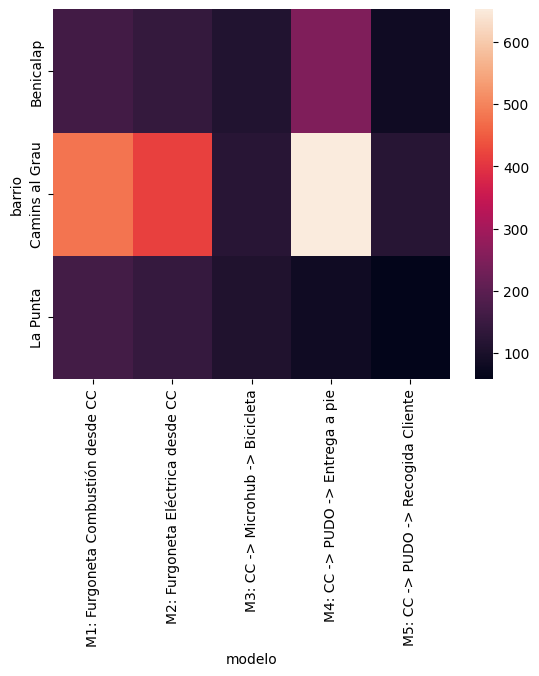

In [27]:
tabla = df_resultados.pivot_table(
    index="barrio",
    columns="modelo",
    values="costo_total_eur"
)

sns.heatmap(tabla)

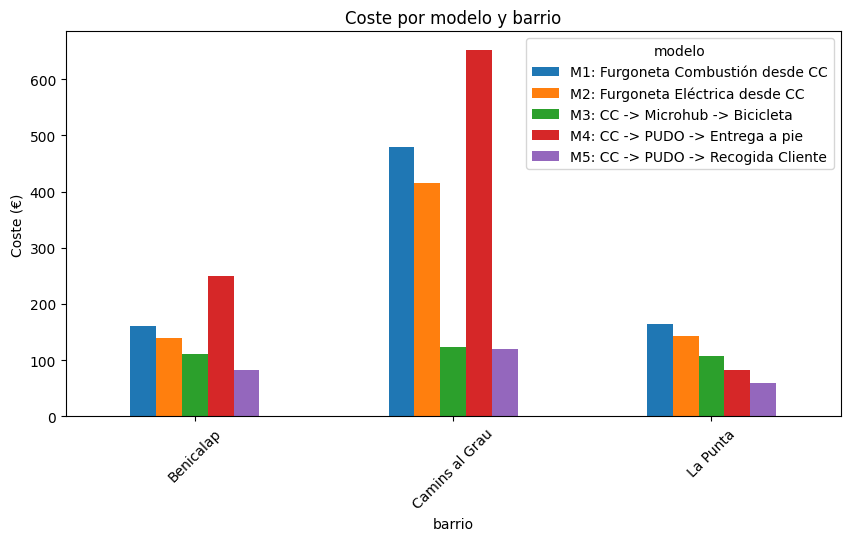

In [28]:
# 1. Coste por modelo y barrio
pivot_coste = df_resultados.pivot_table(
    index="barrio",
    columns="modelo",
    values="costo_total_eur"
)

pivot_coste.plot(kind="bar", figsize=(10, 5))
plt.title("Coste por modelo y barrio")
plt.ylabel("Coste (€)")
plt.xticks(rotation=45)
plt.show()

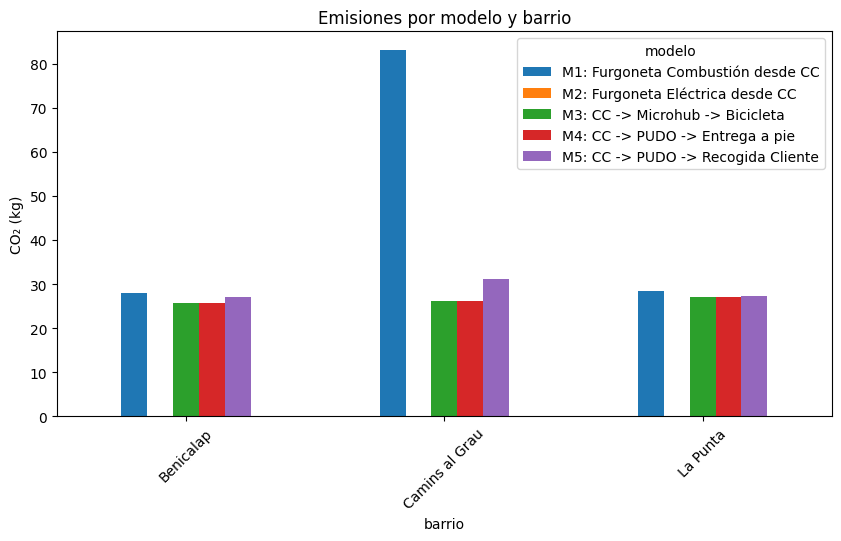

In [29]:
# 2. CO2 por modelo y barrio
pivot_co2 = df_resultados.pivot_table(
    index="barrio",
    columns="modelo",
    values="emisiones_co2_kg"
)

pivot_co2.plot(kind="bar", figsize=(10, 5))
plt.title("Emisiones por modelo y barrio")
plt.ylabel("CO₂ (kg)")
plt.xticks(rotation=45)
plt.show()

In [30]:
# 3. Tabla de ganadores
ganadores = df_resultados.loc[
    df_resultados.groupby("barrio")["costo_total_eur"].idxmin()
]

ganadores[
    ["barrio", "modelo", "costo_total_eur", "emisiones_co2_kg"]
].round(2)

,barrio,modelo,costo_total_eur,emisiones_co2_kg
4,Benicalap,M5: CC -> PUDO -> Recogida Cliente,82.39,27.18
9,Camins al Grau,M5: CC -> PUDO -> Recogida Cliente,120.23,31.25
14,La Punta,M5: CC -> PUDO -> Recogida Cliente,58.45,27.33


In [33]:
results_dir = Path("../results")

archivos = list(results_dir.glob("**/*.csv"))

df_total = pd.concat(
    [pd.read_csv(archivo) for archivo in archivos],
    ignore_index=True
)

df_total.head()

,ciudad,barrio,modelo,centro_logistico,paquetes,distancia_troncal_km,km_recorridos,numero_viajes,emisiones_co2_kg,costo_total_eur
0,barcelona,Ciutat Vella,M1: Furgoneta Combustión desde CC,DCT9 Amazon Logistics,256,6.158339,89.165446,5,19.616398,113.077998
1,barcelona,Ciutat Vella,M2: Furgoneta Eléctrica desde CC,DCT9 Amazon Logistics,256,6.158339,89.165446,5,0.000000,98.081991
2,barcelona,Ciutat Vella,M3: CC -> Microhub -> Bicicleta,DCT9 Amazon Logistics,256,6.158339,44.036038,14,2.709669,83.847833
3,barcelona,Ciutat Vella,M4: CC -> PUDO -> Entrega a pie,DCT9 Amazon Logistics,256,6.158339,423.725666,23,2.709669,1230.633138
4,barcelona,Ciutat Vella,M5: CC -> PUDO -> Recogida Cliente,DCT9 Amazon Logistics,256,6.158339,423.725666,257,12.994894,133.542505


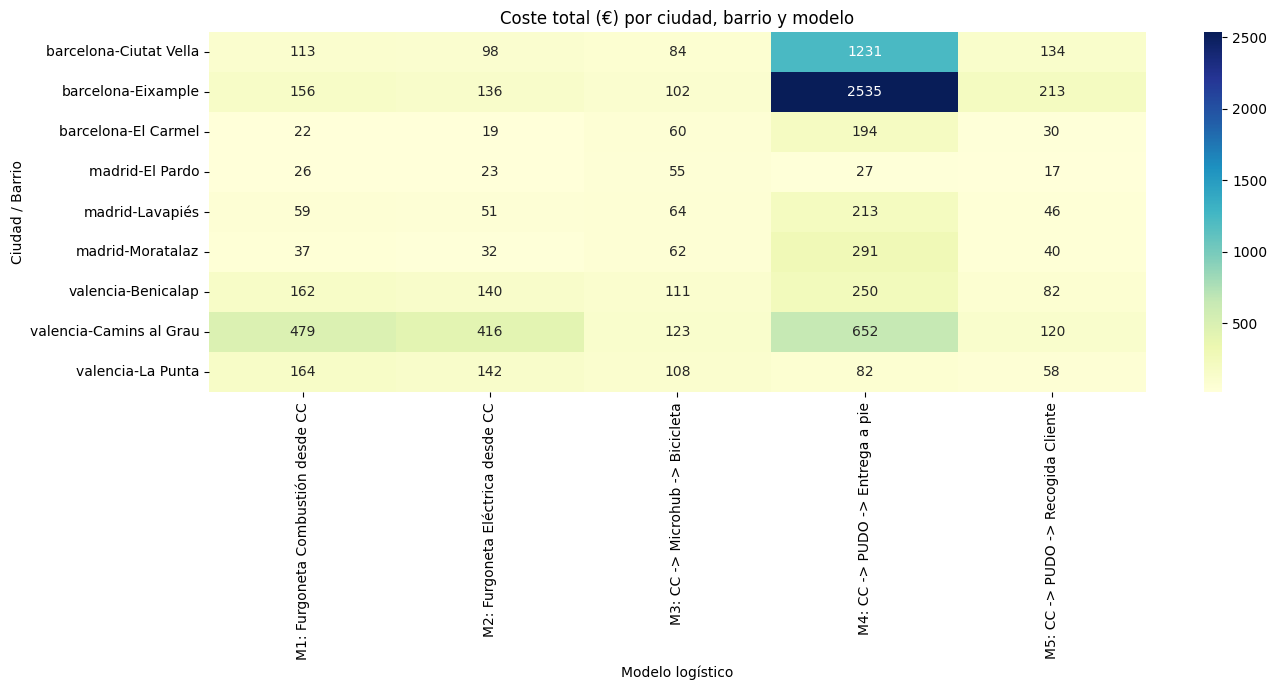

In [34]:
tabla_coste = df_total.pivot_table(
    index=["ciudad", "barrio"],
    columns="modelo",
    values="costo_total_eur",
    aggfunc="mean"
)

plt.figure(figsize=(14, 7))

sns.heatmap(
    tabla_coste,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Coste total (€) por ciudad, barrio y modelo")
plt.xlabel("Modelo logístico")
plt.ylabel("Ciudad / Barrio")

plt.tight_layout()
plt.show()

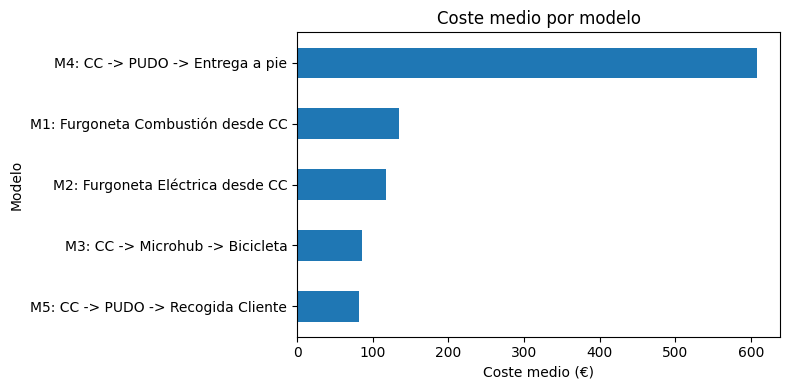

In [35]:
coste_medio = (
    df_total
    .groupby("modelo")["costo_total_eur"]
    .mean()
    .sort_values()
)

coste_medio.plot(
    kind="barh",
    figsize=(8, 4),
    title="Coste medio por modelo"
)

plt.xlabel("Coste medio (€)")
plt.ylabel("Modelo")
plt.tight_layout()
plt.show()

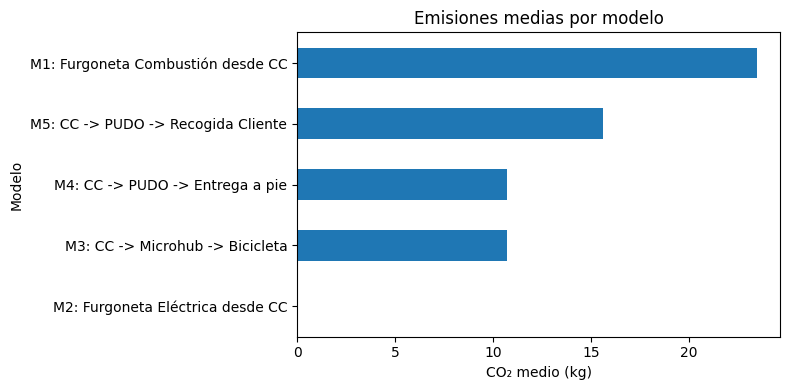

In [36]:
co2_medio = (
    df_total
    .groupby("modelo")["emisiones_co2_kg"]
    .mean()
    .sort_values()
)

co2_medio.plot(
    kind="barh",
    figsize=(8, 4),
    title="Emisiones medias por modelo"
)

plt.xlabel("CO₂ medio (kg)")
plt.ylabel("Modelo")
plt.tight_layout()
plt.show()

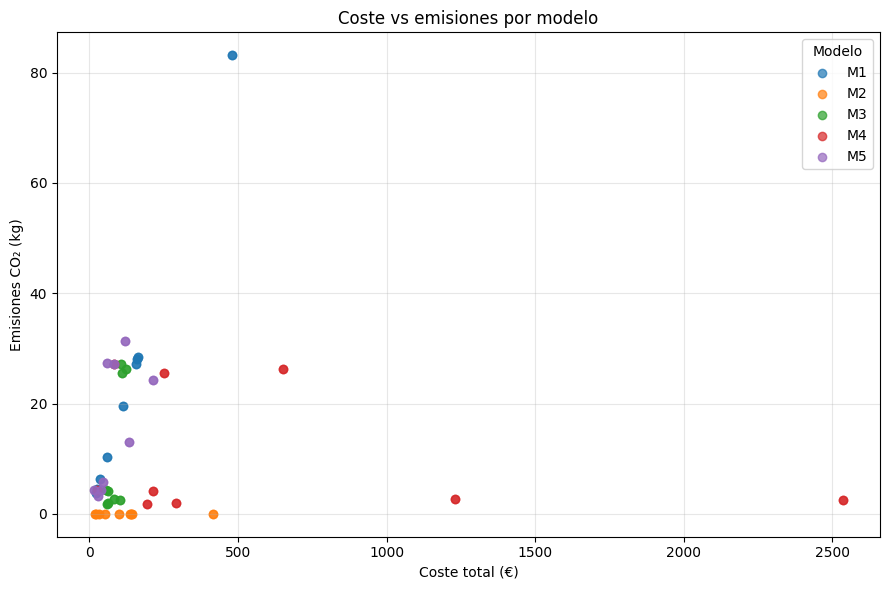

In [37]:
df_plot = df_total.copy()
df_plot["modelo_corto"] = df_plot["modelo"].str.extract(r"(M\d+)")

plt.figure(figsize=(9, 6))

for modelo in df_plot["modelo_corto"].unique():
    subset = df_plot[df_plot["modelo_corto"] == modelo]

    plt.scatter(
        subset["costo_total_eur"],
        subset["emisiones_co2_kg"],
        label=modelo,
        alpha=0.7
    )

plt.title("Coste vs emisiones por modelo")
plt.xlabel("Coste total (€)")
plt.ylabel("Emisiones CO₂ (kg)")
plt.legend(title="Modelo")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()